<a href="https://colab.research.google.com/github/Moysezg/financial-risk-management-var-models/blob/main/03_ewma_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


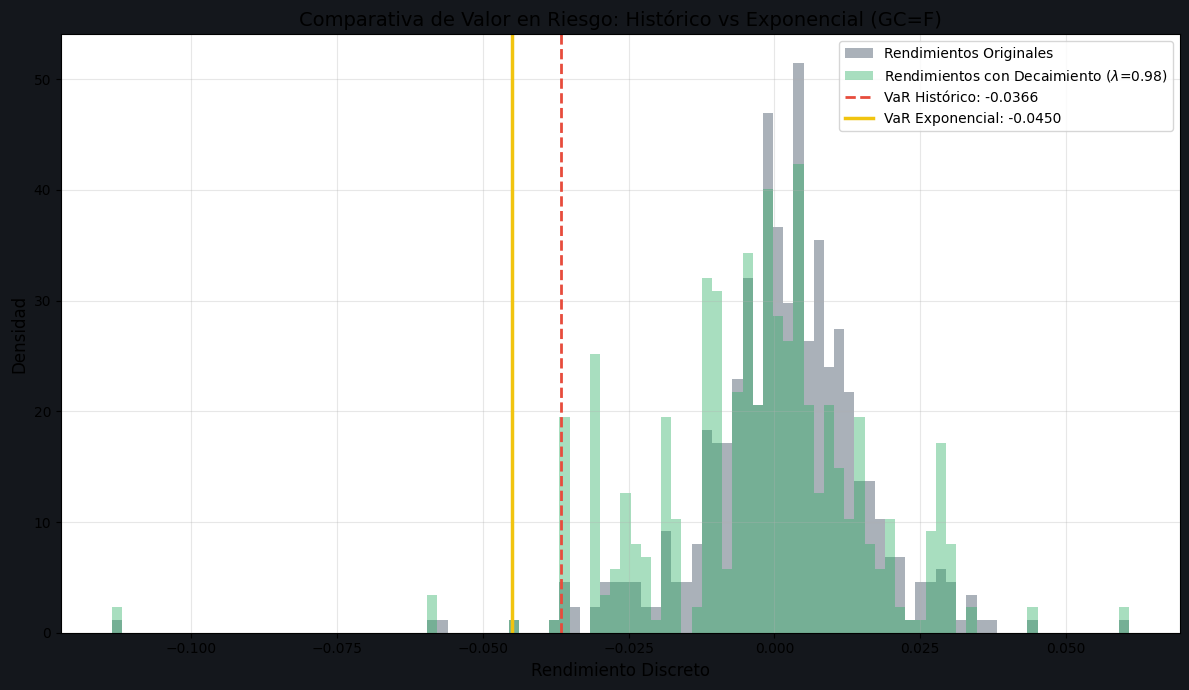

----------------------------------------------------------------------------------------------------
Activo: GC=F | Periodo: 2024-06-22 a 2026-06-22 | Periodicidad: 1d | VaR Histórico (1.0%): -0.036609
Activo: GC=F | Factor Lambda: 0.98 | Periodicidad: 1d | VaR Exponencial (1.0%): -0.045042
----------------------------------------------------------------------------------------------------


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# =============================================================================
# PARÁMETROS DE CONFIGURACIÓN
# =============================================================================
ticker = "GC=F"
años = 2
periodicidad = "1d"
particiones = 100
confianza = 0.01
lam = 0.98               # Factor de decaimiento exponencial (Lambda)

# =============================================================================
# PIPELINE DE PROCESAMIENTO
# =============================================================================

fecha_fin = datetime.now()
fecha_inicio = fecha_fin - timedelta(days=años * 365)

# Se agrega auto_adjust=True para garantizar la descarga de precios ajustados limpios
df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval=periodicidad, auto_adjust=True)

if df.empty:
    print("Error: No se obtuvieron datos.")
else:
    # CORRECCIÓN: Se extrae 'Close' que ya viene ajustado por splits/dividendos
    precios = df['Close']
    rendimientos = precios.pct_change().dropna().to_numpy().flatten()
    n_obs = len(rendimientos)

    # --- CÁLCULO VaR HISTÓRICO TRADICIONAL ---
    var_historico = float(np.percentile(rendimientos, confianza * 100))

    # --- CÁLCULO VaR CON DECAIMIENTO EXPONENCIAL ---
    # 1. Generar pesos secuenciales hacia el pasado
    pesos = np.array([lam**(n_obs - i - 1) for i in range(n_obs)])
    pesos /= pesos.sum() # Normalizar para asegurar sumatoria uniforme = 1

    # 2. Ordenar rendimientos y pesos conjuntamente para encontrar el percentil ponderado
    df_pesos = pd.DataFrame({'ret': rendimientos, 'w': pesos}).sort_values(by='ret')
    df_pesos['w_acum'] = df_pesos['w'].cumsum()
    var_exponencial = df_pesos[df_pesos['w_acum'] >= confianza]['ret'].iloc[0]

    # --- VISUALIZACIÓN ---
    plt.figure(figsize=(12, 7))

    # Histograma Original (Azul)
    plt.hist(rendimientos, bins=particiones, color='#2c3e50', alpha=0.4,
             label='Rendimientos Originales', density=True)

    # Histograma con Pesos Exponenciales (Verde - representación por remuestreo ponderado)
    rendimientos_exp = np.random.choice(rendimientos, size=len(rendimientos), p=pesos)
    plt.hist(rendimientos_exp, bins=particiones, color='#27ae60', alpha=0.4,
             label=rf'Rendimientos con Decaimiento ($\lambda$={lam})', density=True)

    # Marcas de VaR
    plt.axvline(var_historico, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'VaR Histórico: {var_historico:.4f}')
    plt.axvline(var_exponencial, color='#f1c40f', linestyle='-', linewidth=2.5,
                label=f'VaR Exponencial: {var_exponencial:.4f}')

    plt.title(f'Comparativa de Valor en Riesgo: Histórico vs Exponencial ({ticker})', fontsize=14)
    plt.xlabel('Rendimiento Discreto', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- LÍNEAS INFORMATIVAS ---
    print("-" * 100)
    print(f"Activo: {ticker} | Periodo: {fecha_inicio.strftime('%Y-%m-%d')} a {fecha_fin.strftime('%Y-%m-%d')} | "
          f"Periodicidad: {periodicidad} | VaR Histórico ({confianza*100:.1f}%): {var_historico:.6f}")
    print(f"Activo: {ticker} | Factor Lambda: {lam} | "
          f"Periodicidad: {periodicidad} | VaR Exponencial ({confianza*100:.1f}%): {var_exponencial:.6f}")
    print("-" * 100)